<a href="https://colab.research.google.com/github/23f1002879/Pytorch-Computer-Vision/blob/master/projects/PlantDiseaseDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mohitsingh1804_plantvillage_path = kagglehub.dataset_download('mohitsingh1804/plantvillage')

print('Data source import complete.')


Using Colab cache for faster access to the 'plantvillage' dataset.
Data source import complete.


In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Streaming output truncated to the last 5000 lines.
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/33f8d1cd-0773-4a0c-a82d-ec43072cabef___FAM_B.Msls 0876.JPG
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/b7528888-1bc3-4451-8114-2ea432c9184b___FAM_B.Msls 1131.JPG
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/745e8ab5-e315-4357-9145-eec7c2fcf641___FAM_B.Msls 4176.JPG
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/66aff794-a2db-4cc2-a5d2-f78c6e10ef73___FAM_B.Msls 4086.JPG
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/81a1b9ac-4e0e-4bd0-aa3a-ffa4448e34ff___FAM_B.Msls 1828.JPG
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/c9ab1e1c-625e-4d4c-8b64-9eee0d34430a___FAM_B.Msls 4453.JPG
/kaggle/input/plantvillage/PlantVillage/train/Grape___Esca_(Black_Measles)/46270bf8-4d82-4c7e-b1ce-b7abfe81b891___FAM_B.Msls 3854.JPG
/kaggle/inp

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [14]:
trainTransform = transforms.Compose([
    transforms.Resize(
        (224,224)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

testTransform = transforms.Compose([
    transforms.Resize(
        (224,224)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('-'*80)
print('The Training and Test Transform Created Successfully !!!')
print('-'*80)

--------------------------------------------------------------------------------
The Training and Test Transform Created Successfully !!!
--------------------------------------------------------------------------------


In [16]:
# Loading the train and validation datasets
trainDatasets = datasets.ImageFolder(
    root='/kaggle/input/plantvillage/PlantVillage/train',
    transform=trainTransform
)

testDatasets = datasets.ImageFolder(
    root='/kaggle/input/plantvillage/PlantVillage/val',
    transform=testTransform
)

print('-'*80)
print(f'The length of Training Dataset is {len(trainDatasets)}')
print('-'*80)
print('-'*80)
print(f'The length of Test Dataset is {len(testDatasets)}')
print('-'*80)
print(trainDatasets.classes[:5])
print(len(trainDatasets.classes))


--------------------------------------------------------------------------------
The length of Training Dataset is 43444
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
The length of Test Dataset is 10861
--------------------------------------------------------------------------------
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38


In [17]:
# Creating the Train and Test Loaders

trainLoader = DataLoader(
    trainDatasets,
    batch_size = 64,
    shuffle=True,
    num_workers=2
)

testLoader = DataLoader(
    testDatasets,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print('-'*80)
print('Created the Train and Test Loaders Successfully !!!')
print('-'*80)

--------------------------------------------------------------------------------
Created the Train and Test Loaders Successfully !!!
--------------------------------------------------------------------------------


In [18]:
images, labels = next(iter(trainLoader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


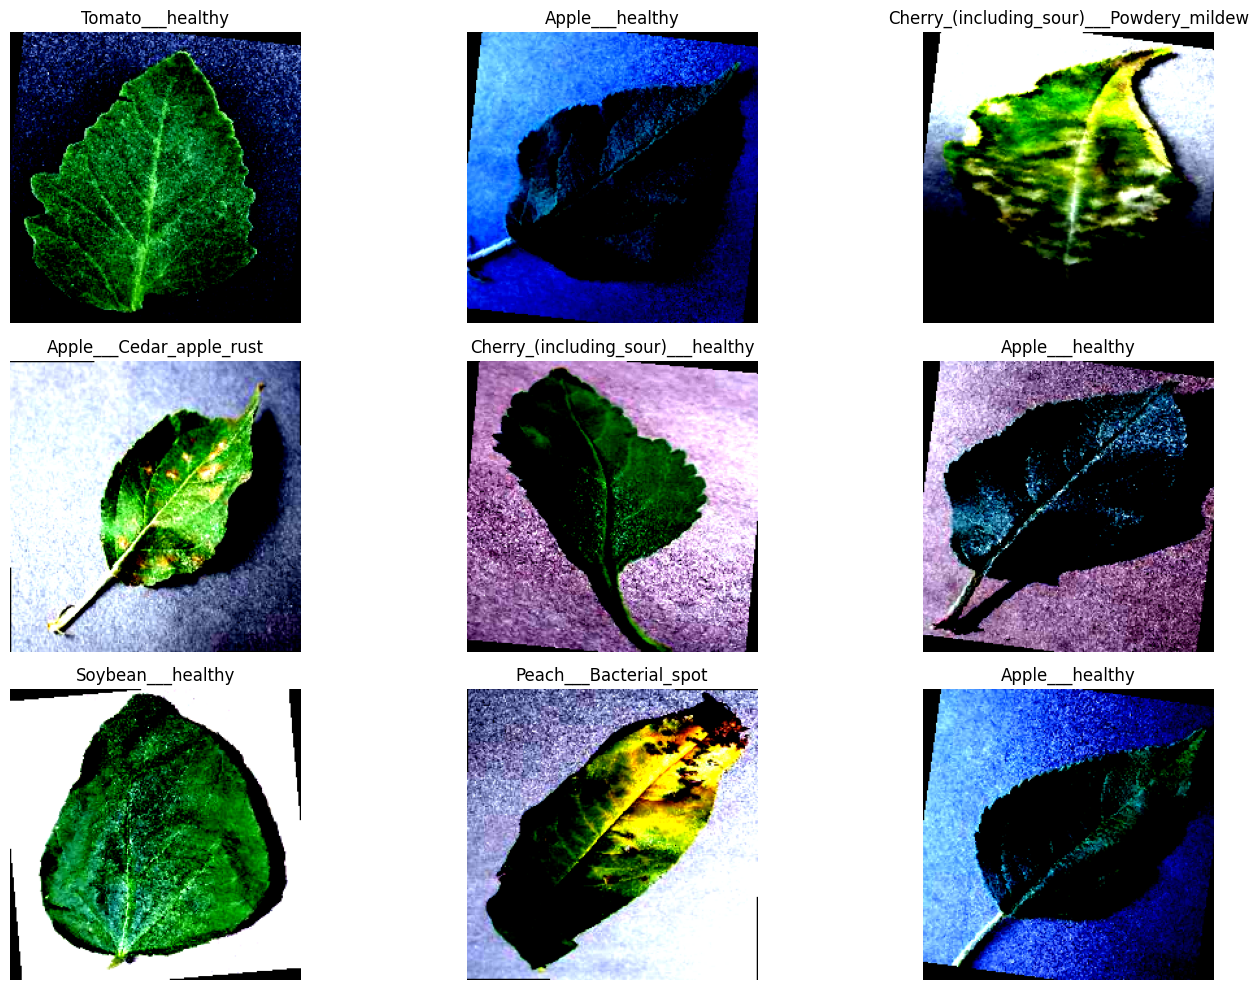

In [19]:
fig, axes = plt.subplots(3,3, figsize=(15,10))

for i, ax in enumerate(axes.flatten()):
    image = images[i].permute(1,2,0)
    ax.imshow(image)
    ax.set_title(
        trainDatasets.classes[
            labels[i]
        ]
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

In [20]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

In [24]:
classFrequency = len(trainDatasets.classes)

model.fc = torch.nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(
        512,
        classFrequency
    )
)

model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [25]:
# Setting Up the loss and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [26]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

# Defining the training function for one epoch
def trainOneEpoch(model, criterion, optimizer, loader, device):
  model.train()
  runningLoss = 0
  total, correct = 0, 0

  for image, label in loader:
    image, label = image.to(device), label.to(device)
    output = model(image)
    loss = criterion(output, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    runningLoss += loss.item()
    _, preds = torch.max(output, 1)
    total += labels.size(0)
    correct += (preds.cpu() == labels).sum().item()

  epoch_loss = runningLoss / len(loader)
  epoch_acc = 100 * correct / total
  return epoch_loss, epoch_acc

In [27]:
# Defining the test function
def validate(model, criterion, loader, device):
  model.eval()
  runningLoss = 0
  total, correct = 0, 0

  with torch.no_grad():
    for image, label in loader:
      image, label = image.to(device), label.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      runningLoss += loss.item()
      _, preds = torch.max(outputs, 1)
      total += labels.size(0)
      correct += (preds.cpu() == labels).sum().item()

  epoch_loss = runningLoss / len(loader)
  epoch_acc = 100 * correct / total
  return epoch_loss, epoch_acc

In [ ]:
epochs = int(input('Enter the number of epochs'))

for epoch in range(epochs):
  train_loss, train_acc = trainOneEpoch(
        model,
        criterion,
        optimizer,
        trainLoader,
        device
    )

  val_loss, val_acc = validate(
      model,
      criterion,
      testLoader,
      device
  )

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  train_accs.append(train_acc)
  val_accs.append(val_acc)

  print(f"Epoch {epoch+1}/{epochs}")

  print(
      f"Train Loss: {train_loss:.4f} | "
      f"Train Acc: {train_acc:.2f}%"
  )

  print(
      f"Val Loss: {val_loss:.4f} | "
      f"Val Acc: {val_acc:.2f}%"
  )

  print("-"*50)

Enter the number of epochs5
